In [1]:
# Install library yang dibutuhakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


# LANGKAH 2: Proses Clustering & Evaluasi Model

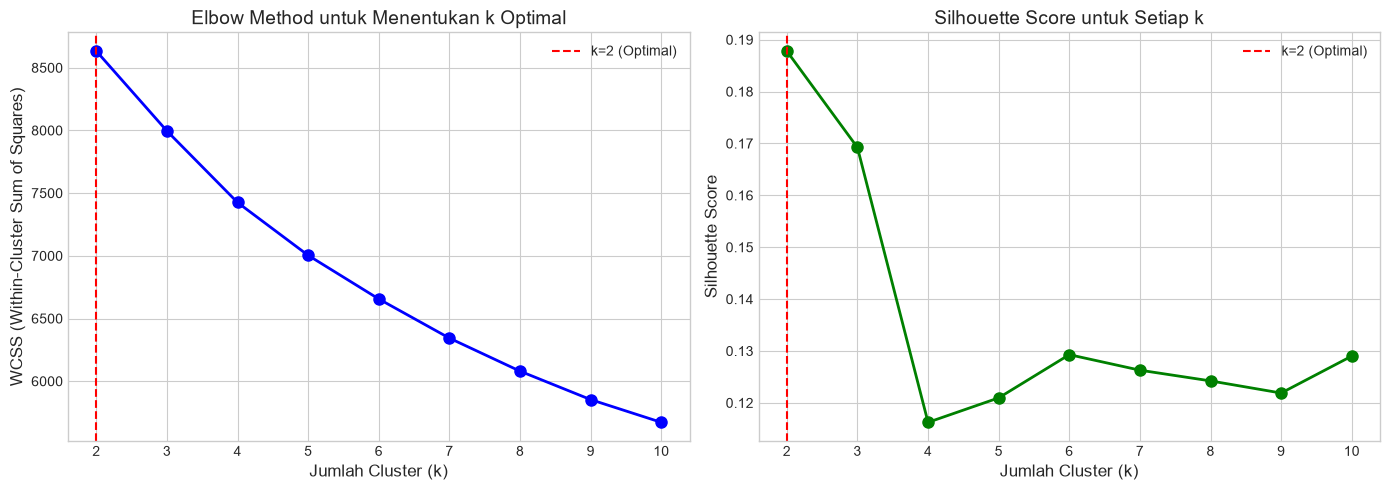


HASIL EVALUASI CLUSTER
 k        WCSS  Silhouette Score
 2 8633.060908          0.187809
 3 7995.650758          0.169225
 4 7425.321353          0.116235
 5 7003.689406          0.120953
 6 6655.790245          0.129283
 7 6343.507334          0.126289
 8 6080.090028          0.124225
 9 5853.247503          0.121883
10 5671.805958          0.129008

 Silhouette Score tertinggi: 0.1878 pada k=2


In [140]:
# Menentukan jumlah cluster optimal menggunakan metode elbow

k_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (k)', fontsize=12)
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method untuk Menentukan k Optimal', fontsize=14)
axes[0].axvline(x=2, color='r', linestyle='--', label='k=2 (Optimal)')
axes[0].legend()

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score untuk Setiap k', fontsize=14)
axes[1].axvline(x=2, color='r', linestyle='--', label='k=2 (Optimal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("HASIL EVALUASI CLUSTER")
print("=" * 60)
eval_df = pd.DataFrame({
    'k': list(k_range),
    'WCSS': wcss,
    'Silhouette Score': silhouette_scores
})
print(eval_df.to_string(index=False))
print(f"\n Silhouette Score tertinggi: {max(silhouette_scores):.4f} pada k={list(k_range)[silhouette_scores.index(max(silhouette_scores))]}")

In [148]:
# K-Means Clustering 

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(df_scaled)

df_fitur['Cluster_KMeans'] = cluster_labels

# Tambahkan cluster ke df_clean juga
df_clean['Cluster_KMeans'] = cluster_labels

silhouette_kmeans = silhouette_score(df_scaled, cluster_labels)
db_kmeans = davies_bouldin_score(df_scaled, cluster_labels)

print("=" * 60)
print("HASIL K-MEANS CLUSTERING (k=2)")
print("=" * 60)
print(f"\n Distribusi Cluster:")
print(df_fitur['Cluster_KMeans'].value_counts().sort_index())

print(f"\nEvaluasi Model:")
print(f"   • Silhouette Score: {silhouette_kmeans:.4f}")
print(f"   • Davies-Bouldin Index: {db_kmeans:.4f}")
print(f"   (Semakin kecil Davies-Bouldin, semakin baik)")
print(f"   (Semakin besar Silhouette, semakin baik)")

print("\n Rata-rata Fitur per Cluster:")
cluster_summary = df_fitur.groupby('Cluster_KMeans')[fitur_kolom].mean()

print(tabulate(cluster_summary.round(2), headers='keys', tablefmt='psql'))

HASIL K-MEANS CLUSTERING (k=2)

 Distribusi Cluster:
Cluster_KMeans
0    418
1    625
Name: count, dtype: int64

Evaluasi Model:
   • Silhouette Score: 0.1878
   • Davies-Bouldin Index: 2.1339
   (Semakin kecil Davies-Bouldin, semakin baik)
   (Semakin besar Silhouette, semakin baik)

 Rata-rata Fitur per Cluster:
+------------------+-----------------+--------------------------------------+---------------+-------+-------------------+------------+-------+-----------------------+---------------+--------------+
|   Cluster_KMeans |   Jenis Kelamin |   Jarak Tempat Tinggal kekampus (Km) |   Tahun Lulus |   SKS |   Ikut Organisasi |   Ikut UKM |   IPK |   Pekerjaan Orang Tua |   Penghasilan |   Tanggungan |
|------------------+-----------------+--------------------------------------+---------------+-------+-------------------+------------+-------+-----------------------+---------------+--------------|
|                0 |            0.5  |                                 0.55 |       2018.8

In [149]:
# Kita gunakan alternatif nya yaitu DBScan clustering

dbscan = DBSCAN(eps=2.5, min_samples=5)
cluster_labels_dbscan = dbscan.fit_predict(df_scaled)

df_fitur['Cluster_DBSCAN'] = cluster_labels_dbscan

valid_mask = cluster_labels_dbscan != -1
if valid_mask.sum() > 0 and len(set(cluster_labels_dbscan[valid_mask])) > 1:
    silhouette_dbscan = silhouette_score(df_scaled[valid_mask], cluster_labels_dbscan[valid_mask])
else:
    silhouette_dbscan = "Tidak dapat dihitung"

print("=" * 60)
print(" HASIL DBSCAN CLUSTERING")
print("=" * 60)
print(f"\n Distribusi Cluster:")
print(df_fitur['Cluster_DBSCAN'].value_counts().sort_index())

print(f"\n Evaluasi Model:")
print(f"   • Silhouette Score: {silhouette_dbscan}")
print(f"   • Noise/Outlier terdeteksi: {(cluster_labels_dbscan == -1).sum()} data")

 HASIL DBSCAN CLUSTERING

 Distribusi Cluster:
Cluster_DBSCAN
-1      11
 0    1032
Name: count, dtype: int64

 Evaluasi Model:
   • Silhouette Score: Tidak dapat dihitung
   • Noise/Outlier terdeteksi: 11 data


In [150]:
# Lanjut kita menggunakan agglomerative clustering

agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
cluster_labels_agglo = agglo.fit_predict(df_scaled)

# Tambahkan label cluster ke dataframe
df_fitur['Cluster_Agglomerative'] = cluster_labels_agglo

# Evaluasi
silhouette_agglo = silhouette_score(df_scaled, cluster_labels_agglo)
db_agglo = davies_bouldin_score(df_scaled, cluster_labels_agglo)

print("=" * 60)
print("HASIL AGGLOMERATIVE CLUSTERING (k=2)")
print("=" * 60)
print(f"\nDistribusi Cluster:")
print(df_fitur['Cluster_Agglomerative'].value_counts().sort_index())

print(f"\n Evaluasi Model:")
print(f"   • Silhouette Score: {silhouette_agglo:.4f}")
print(f"   • Davies-Bouldin Index: {db_agglo:.4f}")

print("\n" + "=" * 60)
print("PERBANDINGAN SEMUA METODE CLUSTERING")
print("=" * 60)
comparison_df = pd.DataFrame({
    'Metode': ['K-Means', 'DBSCAN', 'Agglomerative'],
    'Silhouette': [silhouette_kmeans, silhouette_dbscan if silhouette_dbscan != "Tidak dapat dihitung" else 0, silhouette_agglo],
    'Davies-Bouldin': [db_kmeans, '-', db_agglo]
})
print(comparison_df.to_string(index=False))

HASIL AGGLOMERATIVE CLUSTERING (k=2)

Distribusi Cluster:
Cluster_Agglomerative
0    558
1    485
Name: count, dtype: int64

 Evaluasi Model:
   • Silhouette Score: 0.1381
   • Davies-Bouldin Index: 2.3658

PERBANDINGAN SEMUA METODE CLUSTERING
       Metode  Silhouette Davies-Bouldin
      K-Means    0.187809       2.133857
       DBSCAN    0.000000              -
Agglomerative    0.138145       2.365815


# LANGKAH 3 : Komparasi hasil ground truth vs cluster

In [151]:
# Komparasi hasil ground truth vs cluster

cluster_mapping = {0: 'Cluster_0', 1: 'Cluster_1'}
df_clean['Cluster_KMeans_Label'] = df_clean['Cluster_KMeans'].map(cluster_mapping)
df_clean['Ground_Truth_Label'] = df_clean['Ground_Truth'].map({1: 'Terima Beasiswa', 0: 'Tidak Terima'})

# Crosstab K-Means
print("=" * 60)
print("CROSSTAB: Ground Truth vs K-Means Cluster")
print("=" * 60)
crosstab_kmeans = pd.crosstab(
    df_clean['Ground_Truth_Label'], 
    df_clean['Cluster_KMeans_Label'],
    margins=True,
    margins_name='Total'
)
print(crosstab_kmeans)

# Hitung persentase
print("\n Persentase per Baris:")
crosstab_pct = pd.crosstab(
    df_clean['Ground_Truth_Label'], 
    df_clean['Cluster_KMeans_Label'],
    normalize='index'
) * 100
print(crosstab_pct.round(2))

CROSSTAB: Ground Truth vs K-Means Cluster
Cluster_KMeans_Label  Cluster_0  Cluster_1  Total
Ground_Truth_Label                               
Terima Beasiswa             202         70    272
Tidak Terima                216        555    771
Total                       418        625   1043

 Persentase per Baris:
Cluster_KMeans_Label  Cluster_0  Cluster_1
Ground_Truth_Label                        
Terima Beasiswa           74.26      25.74
Tidak Terima              28.02      71.98


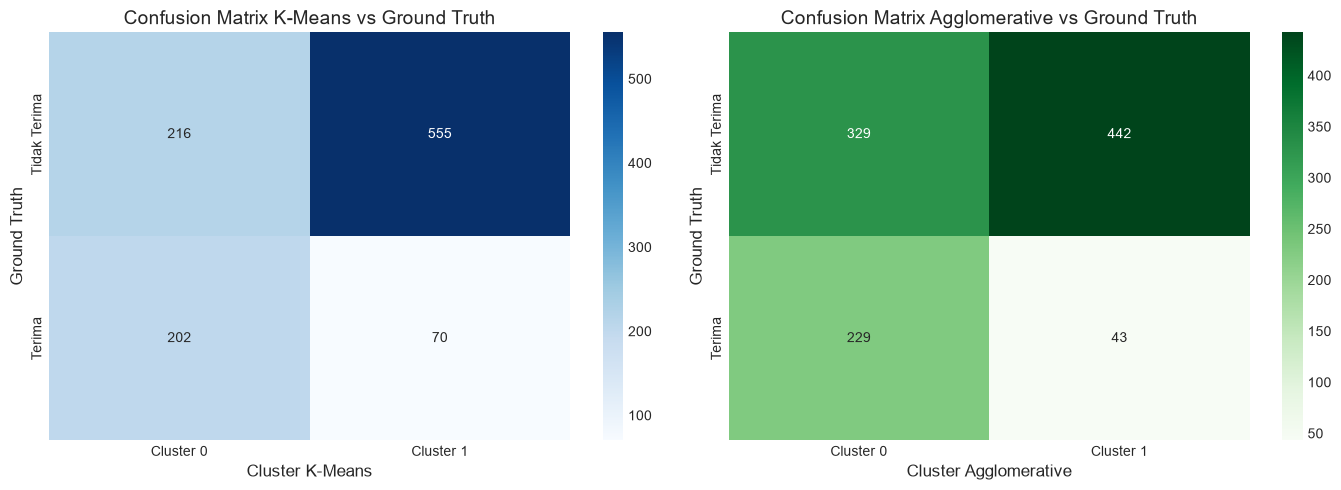


INTERPRETASI CONFUSION MATRIX

K-Means:
  • True Positive (TP): 70 - Diterima & di Cluster Layak
  • True Negative (TN): 216 - Ditolak & di Cluster Tidak Layak
  • False Positive (FP): 555 - Ditolak tapi di Cluster Layak 
  • False Negative (FN): 202 - Diterima tapi di Cluster Tidak Layak

  Match: 286 (27.4%)
   Mismatch: 757 (72.6%)


In [160]:
# Confusion Matrix

# print(df_clean['Ground_Truth'])




cm_kmeans = confusion_matrix(df_clean['Ground_Truth'], df_clean['Cluster_KMeans'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix K-Means
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Tidak Terima', 'Terima'])
axes[0].set_xlabel('Cluster K-Means', fontsize=12)
axes[0].set_ylabel('Ground Truth', fontsize=12)
axes[0].set_title('Confusion Matrix K-Means vs Ground Truth', fontsize=14)

# Confusion Matrix Agglomerative
cm_agglo = confusion_matrix(df_clean['Ground_Truth'], df_fitur['Cluster_Agglomerative'])
sns.heatmap(cm_agglo, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Tidak Terima', 'Terima'])
axes[1].set_xlabel('Cluster Agglomerative', fontsize=12)
axes[1].set_ylabel('Ground Truth', fontsize=12)
axes[1].set_title('Confusion Matrix Agglomerative vs Ground Truth', fontsize=14)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("INTERPRETASI CONFUSION MATRIX")
print("=" * 60)
print(f"\nK-Means:")
print(f"  • True Positive (TP): {cm_kmeans[1,1]} - Diterima & di Cluster Layak")
print(f"  • True Negative (TN): {cm_kmeans[0,0]} - Ditolak & di Cluster Tidak Layak")
print(f"  • False Positive (FP): {cm_kmeans[0,1]} - Ditolak tapi di Cluster Layak ")
print(f"  • False Negative (FN): {cm_kmeans[1,0]} - Diterima tapi di Cluster Tidak Layak")

# Identifikasi mismatch
total_data = cm_kmeans.sum()
mismatch = cm_kmeans[0,1] + cm_kmeans[1,0]
match = cm_kmeans[0,0] + cm_kmeans[1,1]
print(f"\n  Match: {match} ({match/total_data*100:.1f}%)")
print(f"   Mismatch: {mismatch} ({mismatch/total_data*100:.1f}%)")
